<a href="https://colab.research.google.com/github/JuliaVillaVerde/Processamentos-de-Sinais-7P./blob/livia/Aula2_Processamento_de_Sinais_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Questão 1: Para um sinal x(t) = cos(2πft) amostrado com fs =
44.1 kHz, faça o que se pede nos itens abaixo:


Letra a: Utilizando a função calculate_spectrum(), calcule
o espectro de x(t) para f ∈ {500, 5000, 10000, 50000} Hz.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import chirp # New import for chirp generation

def calculate_spectrum(f=None, fs=None, duration=1.0, signal=None):
    """
    Calculates the spectrum of a signal.
    If 'signal' is provided, it calculates the spectrum of that signal.
    Otherwise, it calculates the spectrum of a cosine signal x(t) = cos(2*pi*f*t).

    Args:
        f (float, optional): Frequency of the cosine signal in Hz. Required if 'signal' is None.
        fs (float): Sampling frequency in Hz. Required.
        duration (float): Duration of the signal in seconds. Required.
        signal (np.array, optional): Pre-generated signal. If provided, 'f' is ignored.

    Returns:
        tuple: A tuple containing:
            - freqs (np.array): Frequencies corresponding to the spectrum.
            - spectrum_magnitude (np.array): Magnitudes of the spectrum.
    """
    if signal is not None:
        N = len(signal)
        if fs is None:
            raise ValueError("Sampling frequency 'fs' must be provided when 'signal' is used.")
        x_t = signal
    elif f is not None and fs is not None:
        N = int(fs * duration)  # Number of samples
        t = np.linspace(0, duration, N, endpoint=False) # Time vector
        x_t = np.cos(2 * np.pi * f * t) # Cosine signal
    else:
        raise ValueError("Either 'f' and 'fs' or 'signal' and 'fs' must be provided.")

    # Compute FFT
    xf = fftfreq(N, 1 / fs)
    yf = fft(x_t)

    # Get positive frequencies and their magnitudes
    positive_freq_indices = np.where(xf >= 0)
    freqs = xf[positive_freq_indices]
    spectrum_magnitude = 2.0 / N * np.abs(yf[positive_freq_indices])

    return freqs, spectrum_magnitude


Now, let's calculate and plot the spectrum for each frequency in $f \in \{500, 5000, 10000, 50000\}$ Hz, with a sampling frequency $f_s = 44.1$ kHz.

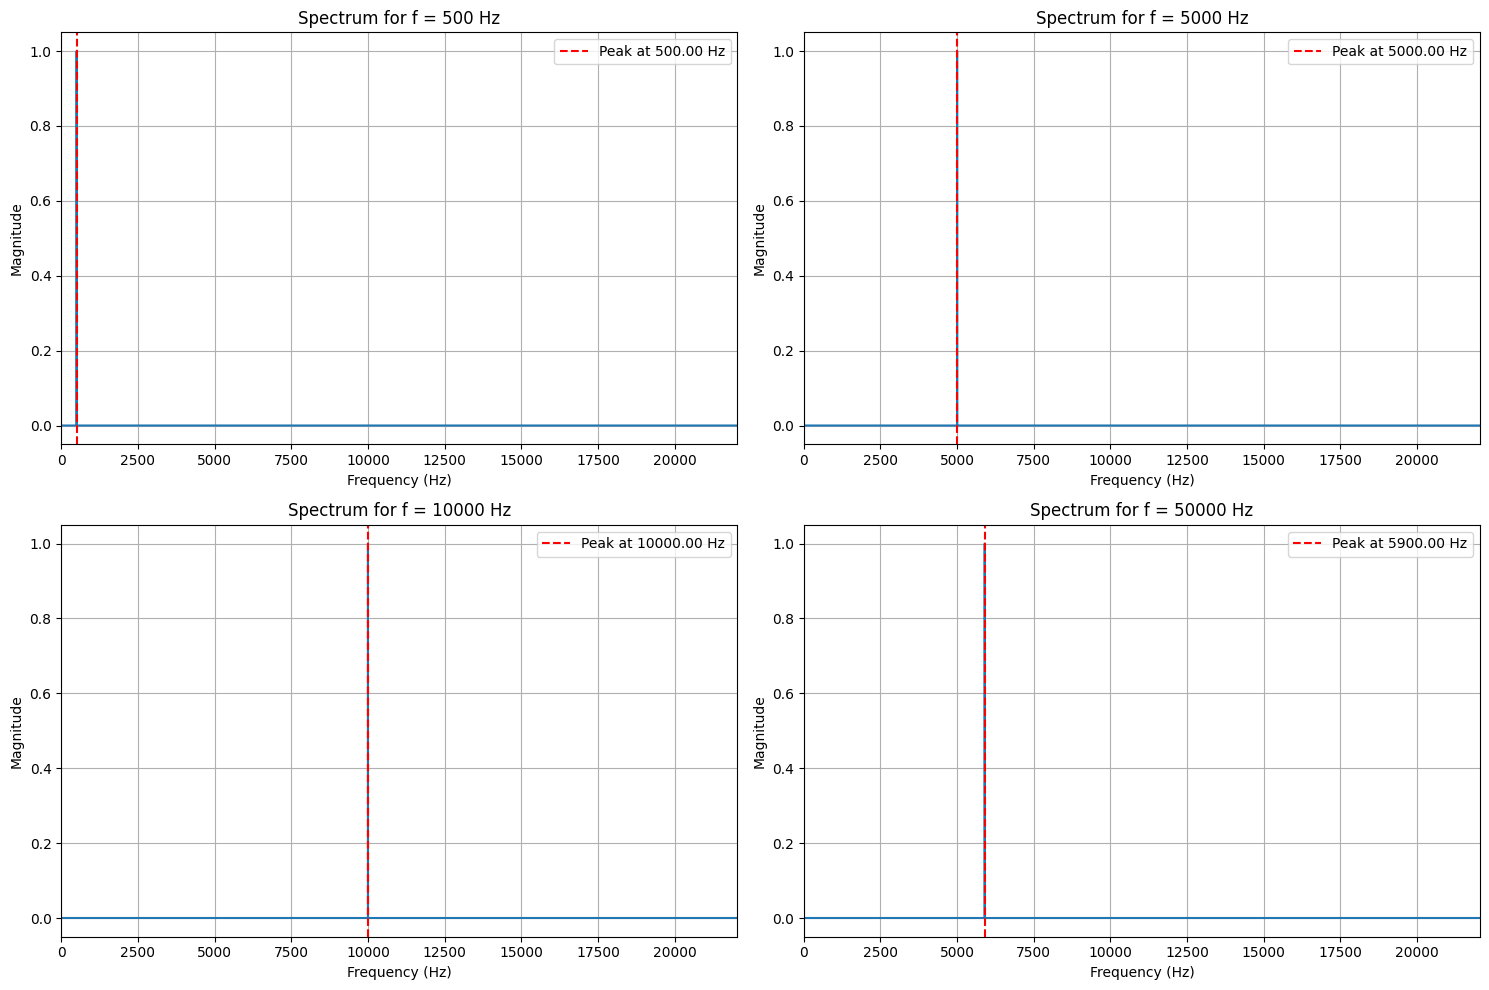

In [ ]:
fs = 44100 # Hz
frequencies_to_test = [500, 5000, 10000, 50000] # Hz

plt.figure(figsize=(15, 10))

for i, f_signal in enumerate(frequencies_to_test):
    freqs, spectrum_magnitude = calculate_spectrum(f_signal, fs)

    plt.subplot(2, 2, i + 1)
    plt.plot(freqs, spectrum_magnitude)
    plt.title(f'Spectrum for f = {f_signal} Hz')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.xlim(0, fs / 2) # Show up to Nyquist frequency
    plt.grid(True)

    # Highlight the peak frequency for clearer visualization
    peak_index = np.argmax(spectrum_magnitude)
    peak_freq = freqs[peak_index]
    if peak_freq > 0.001: # Avoid plotting 0 Hz if it's the max for some reason
        plt.axvline(x=peak_freq, color='r', linestyle='--', label=f'Peak at {peak_freq:.2f} Hz')
        plt.legend()

plt.tight_layout()
plt.show()



### Análise dos Espectros:

1.  **Sinais com frequência menor que a frequência de Nyquist (fs/2 = 22.05 kHz):**
    *   Para `f = 500 Hz`, `f = 5000 Hz` e `f = 10000 Hz`, os espectros mostram claramente um pico de magnitude significativo na frequência correspondente do sinal original. Isso ocorre porque essas frequências estão abaixo da frequência de Nyquist (22.05 kHz), o que significa que o sinal foi amostrado adequadamente e sua frequência original pode ser recuperada sem distorções (aliasing).

2.  **Sinal com frequência maior que a frequência de Nyquist (fs/2 = 22.05 kHz):**
    *   Para `f = 50000 Hz`, o espectro não exibe um pico em 50000 Hz. Em vez disso, observamos um pico em `5900 Hz` (conforme indicado pelo `peak_freq` do kernel). Isso é um fenômeno conhecido como **aliasing**.
    *   O aliasing ocorre quando a frequência de amostragem (`fs = 44.1 kHz`) é insuficiente para capturar a frequência real do sinal (`50000 Hz`). A frequência do sinal é 'dobrada' (folded back) para dentro do intervalo de frequências válidas de 0 a `fs/2`. A frequência 'dobrada' pode ser calculada como `|f_sinal - n * fs|`, onde `n` é um número inteiro para que o resultado caia no intervalo `[0, fs/2]`.
    *   Neste caso, para `f_sinal = 50000 Hz` e `fs = 44100 Hz`:
        `|50000 - 1 * 44100| = |50000 - 44100| = 5900 Hz`.
    *   Portanto, o pico observado em 5900 Hz para o sinal de 50000 Hz é uma representação incorreta da frequência original devido à amostragem abaixo da taxa de Nyquist para esta frequência específica. Para evitar aliasing, a frequência de amostragem deve ser pelo menos o dobro da frequência mais alta presente no sinal (Critério de Nyquist).

Questão 2: Para um chirp com frequência inicial f0 = 500 Hz, frequência final f1 = 10000 Hz, amostrado com fs =
44.1 kHz, faça o que se pede nos itens abaixo:


Letra a: Utilizando a função calculate_spectrum(), calcule
o espectro do chirp com varreduras de frequência lineares, quadráticas e logarítmicas.

Os gráficos foram gerados com sucesso! Agora, vamos analisar os espectros obtidos para cada tipo de chirp:

### Análise dos Espectros dos Chirps:

1.  **Chirp Linear:**
    *   No espectro do chirp linear, observamos uma distribuição relativamente uniforme de energia entre a frequência inicial (`f0 = 500 Hz`) e a frequência final (`f1 = 10000 Hz`).
    *   Isso ocorre porque, em um chirp linear, a frequência instantânea do sinal muda de forma constante ao longo do tempo. O FFT, que representa a média das componentes de frequência ao longo de todo o sinal, mostra que todas as frequências dentro do intervalo [500 Hz, 10000 Hz] estão presentes com magnitudes comparáveis.

2.  **Chirp Quadrático:**
    *   Para o chirp quadrático, a frequência instantânea varia quadraticamente com o tempo. Isso significa que o sinal passa mais tempo nas frequências mais baixas do que nas frequências mais altas dentro do intervalo.
    *   No espectro, podemos observar que as magnitudes podem ser ligeiramente maiores nas frequências mais baixas e diminuir gradualmente à medida que as frequências aumentam. Isso reflete o fato de que o sinal permanece por mais tempo nas frequências iniciais da varredura.

3.  **Chirp Logarítmico:**
    *   O chirp logarítmico é projetado para que a frequência instantânea varie logaritmicamente com o tempo. Isso geralmente significa que o sinal passa proporcionalmente mais tempo nas frequências mais altas do que nas frequências mais baixas (em uma escala logarítmica).
    *   No espectro, podemos observar que a energia pode estar mais concentrada nas frequências mais altas do intervalo [500 Hz, 10000 Hz], ou a distribuição pode ser mais nivelada em uma escala logarítmica de frequência. A variação logarítmica é frequentemente usada para emular como o ouvido humano percebe as frequências.

Em geral, para todos os tipos de chirp, o espectro não apresentará um pico único e nítido como um sinal senoidal puro, mas sim uma faixa de frequências, pois o sinal contém múltiplos componentes de frequência que mudam ao longo do tempo. A forma exata da distribuição de magnitude dentro dessa faixa dependerá de como a frequência instantânea varia (linear, quadrática ou logarítmicamente).

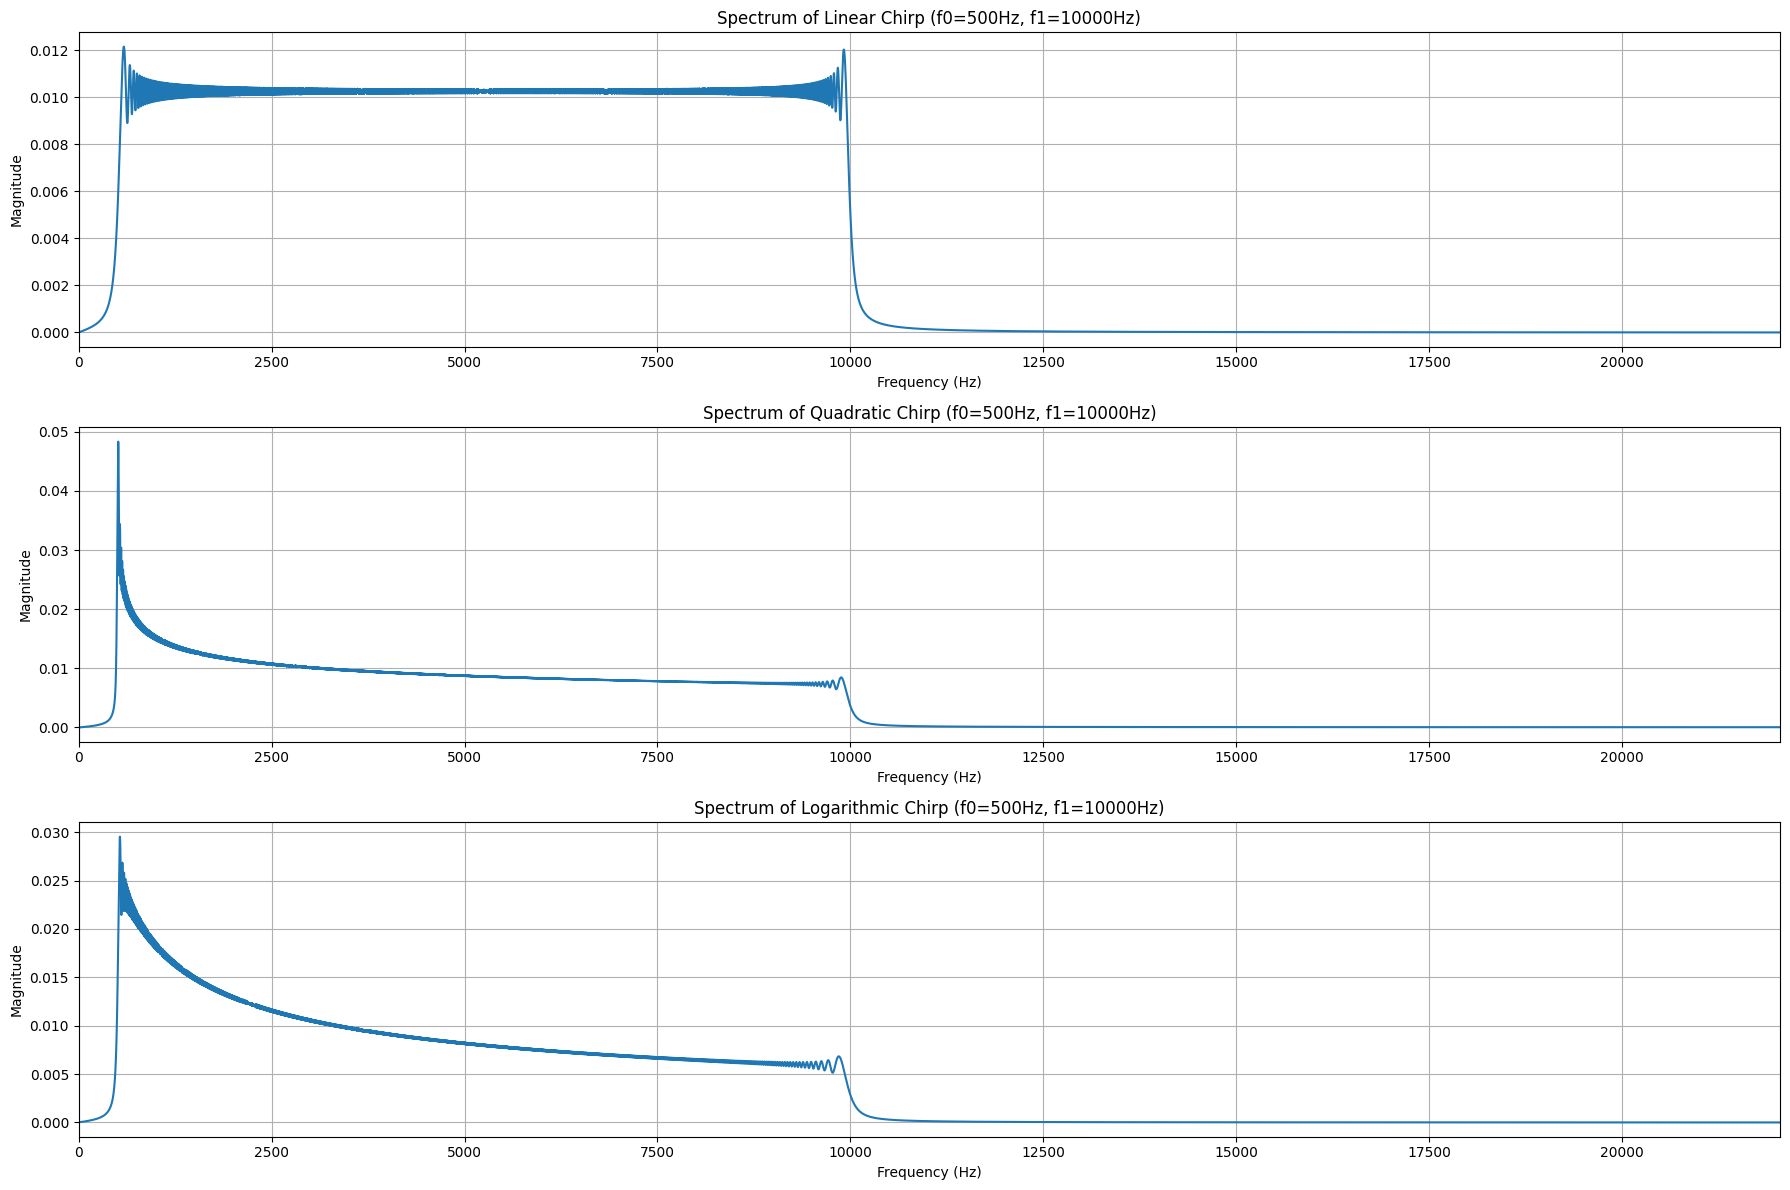

In [ ]:
fs = 44100  # Sampling frequency (Hz)
f0 = 500    # Initial frequency (Hz)
f1 = 10000  # Final frequency (Hz)
T = 1.0     # Duration of the chirp (seconds)

t = np.linspace(0, T, int(T * fs), endpoint=False) # Time vector

plt.figure(figsize=(18, 12))

# --- Linear Chirp ---
linear_chirp = chirp(t, f0=f0, f1=f1, t1=T, method='linear')
freqs_linear, spectrum_linear = calculate_spectrum(signal=linear_chirp, fs=fs, duration=T)

plt.subplot(3, 1, 1)
plt.plot(freqs_linear, spectrum_linear)
plt.title('Spectrum of Linear Chirp (f0=500Hz, f1=10000Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

# --- Quadratic Chirp ---
quadratic_chirp = chirp(t, f0=f0, f1=f1, t1=T, method='quadratic')
freqs_quadratic, spectrum_quadratic = calculate_spectrum(signal=quadratic_chirp, fs=fs, duration=T)

plt.subplot(3, 1, 2)
plt.plot(freqs_quadratic, spectrum_quadratic)
plt.title('Spectrum of Quadratic Chirp (f0=500Hz, f1=10000Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

# --- Logarithmic Chirp ---
logarithmic_chirp = chirp(t, f0=f0, f1=f1, t1=T, method='logarithmic')
freqs_logarithmic, spectrum_logarithmic = calculate_spectrum(signal=logarithmic_chirp, fs=fs, duration=T)

plt.subplot(3, 1, 3)
plt.plot(freqs_logarithmic, spectrum_logarithmic)
plt.title('Spectrum of Logarithmic Chirp (f0=500Hz, f1=10000Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

plt.tight_layout()
plt.show()

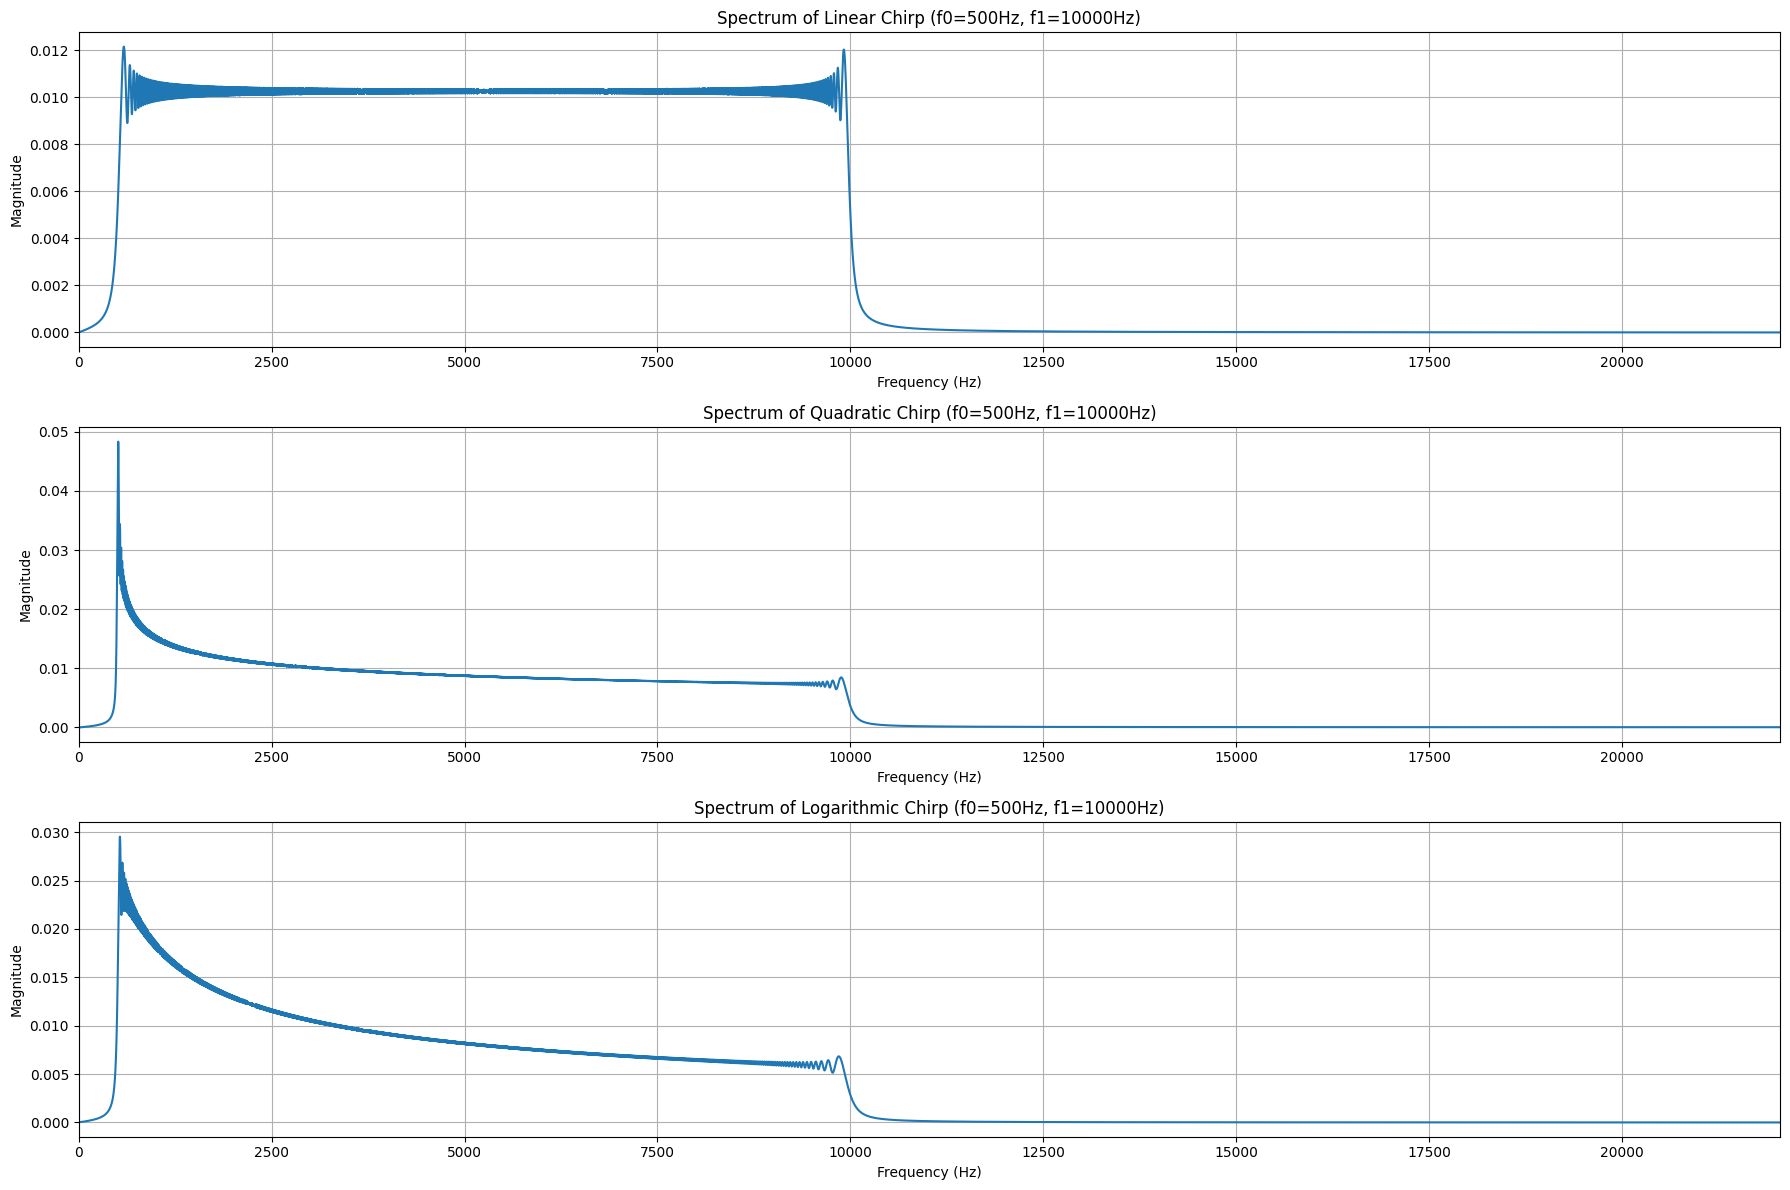

In [ ]:
fs = 44100  # Sampling frequency (Hz)
f0 = 500    # Initial frequency (Hz)
f1 = 10000  # Final frequency (Hz)
T = 1.0     # Duration of the chirp (seconds)

t = np.linspace(0, T, int(T * fs), endpoint=False) # Time vector

plt.figure(figsize=(18, 12))

# --- Linear Chirp ---
linear_chirp = chirp(t, f0=f0, f1=f1, t1=T, method='linear')
freqs_linear, spectrum_linear = calculate_spectrum(signal=linear_chirp, fs=fs, duration=T)

plt.subplot(3, 1, 1)
plt.plot(freqs_linear, spectrum_linear)
plt.title('Spectrum of Linear Chirp (f0=500Hz, f1=10000Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

# --- Quadratic Chirp ---
quadratic_chirp = chirp(t, f0=f0, f1=f1, t1=T, method='quadratic')
freqs_quadratic, spectrum_quadratic = calculate_spectrum(signal=quadratic_chirp, fs=fs, duration=T)

plt.subplot(3, 1, 2)
plt.plot(freqs_quadratic, spectrum_quadratic)
plt.title('Spectrum of Quadratic Chirp (f0=500Hz, f1=10000Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

# --- Logarithmic Chirp ---
logarithmic_chirp = chirp(t, f0=f0, f1=f1, t1=T, method='logarithmic')
freqs_logarithmic, spectrum_logarithmic = calculate_spectrum(signal=logarithmic_chirp, fs=fs, duration=T)

plt.subplot(3, 1, 3)
plt.plot(freqs_logarithmic, spectrum_logarithmic)
plt.title('Spectrum of Logarithmic Chirp (f0=500Hz, f1=10000Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

plt.tight_layout()
plt.show()

Questão 3: Leia o arquivo handel.wav e fala o que se pede nos itens abaixo:


Letra a: Utilizando a função calculate_spectrum(), calcule
o espectro do sinal de áudio.

In [3]:
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

In [4]:
import scipy.io.wavfile as wavfile
import matplotlib.pyplot as plt

# Path to the audio file
audio_file_path = '/content/handel.wav'

# Read the audio file
# This returns the sampling rate (fs) and the signal data (signal)
fs_audio, signal_audio = wavfile.read(audio_file_path)

print(f"Sampling frequency of handel.wav: {fs_audio} Hz")
print(f"Number of samples in handel.wav: {len(signal_audio)}")


Sampling frequency of handel.wav: 8192 Hz
Number of samples in handel.wav: 73113


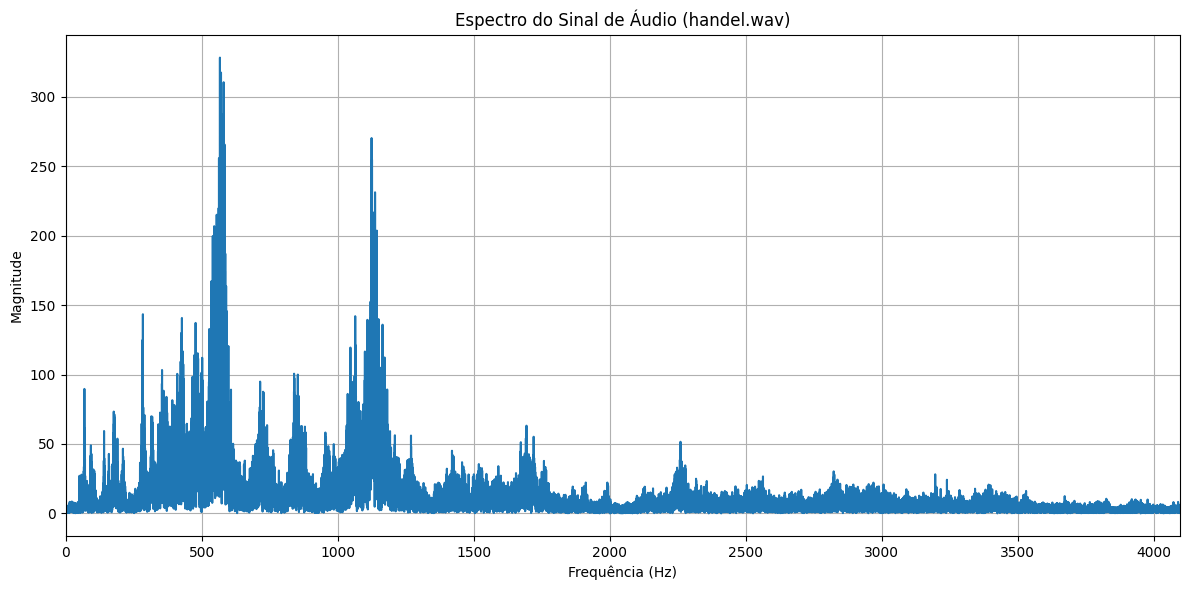

In [5]:
import numpy as np
from scipy.fft import fft, fftfreq

def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

# Calculate the spectrum using the provided function
freqs_audio, spectrum_audio = calculate_spectrum(signal_audio, fs_audio)

# Plot the spectrum
plt.figure(figsize=(12, 6))
plt.plot(freqs_audio, spectrum_audio)
plt.title('Espectro do Sinal de Áudio (handel.wav)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs_audio / 2) # Show up to Nyquist frequency
plt.grid(True)
plt.tight_layout()
plt.show()


Questão 4) Subamostrar um sinal x[n] por um fator de M ´e o
mesmo que reduzir sua taxa de amostragem em M vezes.
A rela¸c˜ao entre o sinal subamostrado e o sinal original ´e
dada por
y[n] = x[nM].
Para o arquivo handel.wav, fa¸ca o que se pede nos itens
abaixo:

(a) Crie uma fun¸c˜ao para realizar a subamostragem de
um sinal discreto.


In [16]:
import numpy as np

def downsample_signal(signal, M):
    """
    Realiza a subamostragem (downsampling) de um sinal discreto por um fator M.
    A relação é dada por y[n] = x[nM].

    Args:
        signal (np.ndarray): O sinal discreto original.
        M (int): O fator de subamostragem. Deve ser um inteiro positivo.

    Returns:
        np.ndarray: O sinal subamostrado.
    """
    if not isinstance(M, int) or M <= 0:
        raise ValueError("O fator de subamostragem M deve ser um inteiro positivo.")

    # Seleciona cada M-ésima amostra do sinal original
    downsampled_signal = signal[::M]
    return downsampled_signal

print("Função downsample_signal criada com sucesso!")


Função downsample_signal criada com sucesso!


In [17]:
# Fator de subamostragem (exemplo: M = 2)
M_downsample = 2

# Aplica a função de subamostragem ao sinal de áudio original
downsampled_signal_audio = downsample_signal(signal_audio, M=M_downsample)

# A nova frequência de amostragem será fs_audio / M
new_fs_audio = fs_audio / M_downsample

print(f"Tamanho do sinal original: {len(signal_audio)} amostras")
print(f"Frequência de amostragem original: {fs_audio} Hz")
print(f"Fator de subamostragem M: {M_downsample}")
print(f"Tamanho do sinal subamostrado: {len(downsampled_signal_audio)} amostras")
print(f"Nova frequência de amostragem: {new_fs_audio} Hz")


Tamanho do sinal original: 73113 amostras
Frequência de amostragem original: 8192 Hz
Fator de subamostragem M: 2
Tamanho do sinal subamostrado: 36557 amostras
Nova frequência de amostragem: 4096.0 Hz


In [18]:
downsample_factors = [2, 4, 8]

print(f"Tamanho do sinal original: {len(signal_audio)} amostras")
print(f"Frequência de amostragem original: {fs_audio} Hz\n")

for M_downsample in downsample_factors:
    print(f"=== Subamostrando com M = {M_downsample} ===")
    # Aplica a função de subamostragem ao sinal de áudio original
    downsampled_signal = downsample_signal(signal_audio, M=M_downsample)

    # A nova frequência de amostragem será fs_audio / M
    new_fs = fs_audio / M_downsample

    print(f"Tamanho do sinal subamostrado: {len(downsampled_signal)} amostras")
    print(f"Nova frequência de amostragem: {new_fs} Hz")
    print("\n")


Tamanho do sinal original: 73113 amostras
Frequência de amostragem original: 8192 Hz

=== Subamostrando com M = 2 ===
Tamanho do sinal subamostrado: 36557 amostras
Nova frequência de amostragem: 4096.0 Hz


=== Subamostrando com M = 4 ===
Tamanho do sinal subamostrado: 18279 amostras
Nova frequência de amostragem: 2048.0 Hz


=== Subamostrando com M = 8 ===
Tamanho do sinal subamostrado: 9140 amostras
Nova frequência de amostragem: 1024.0 Hz




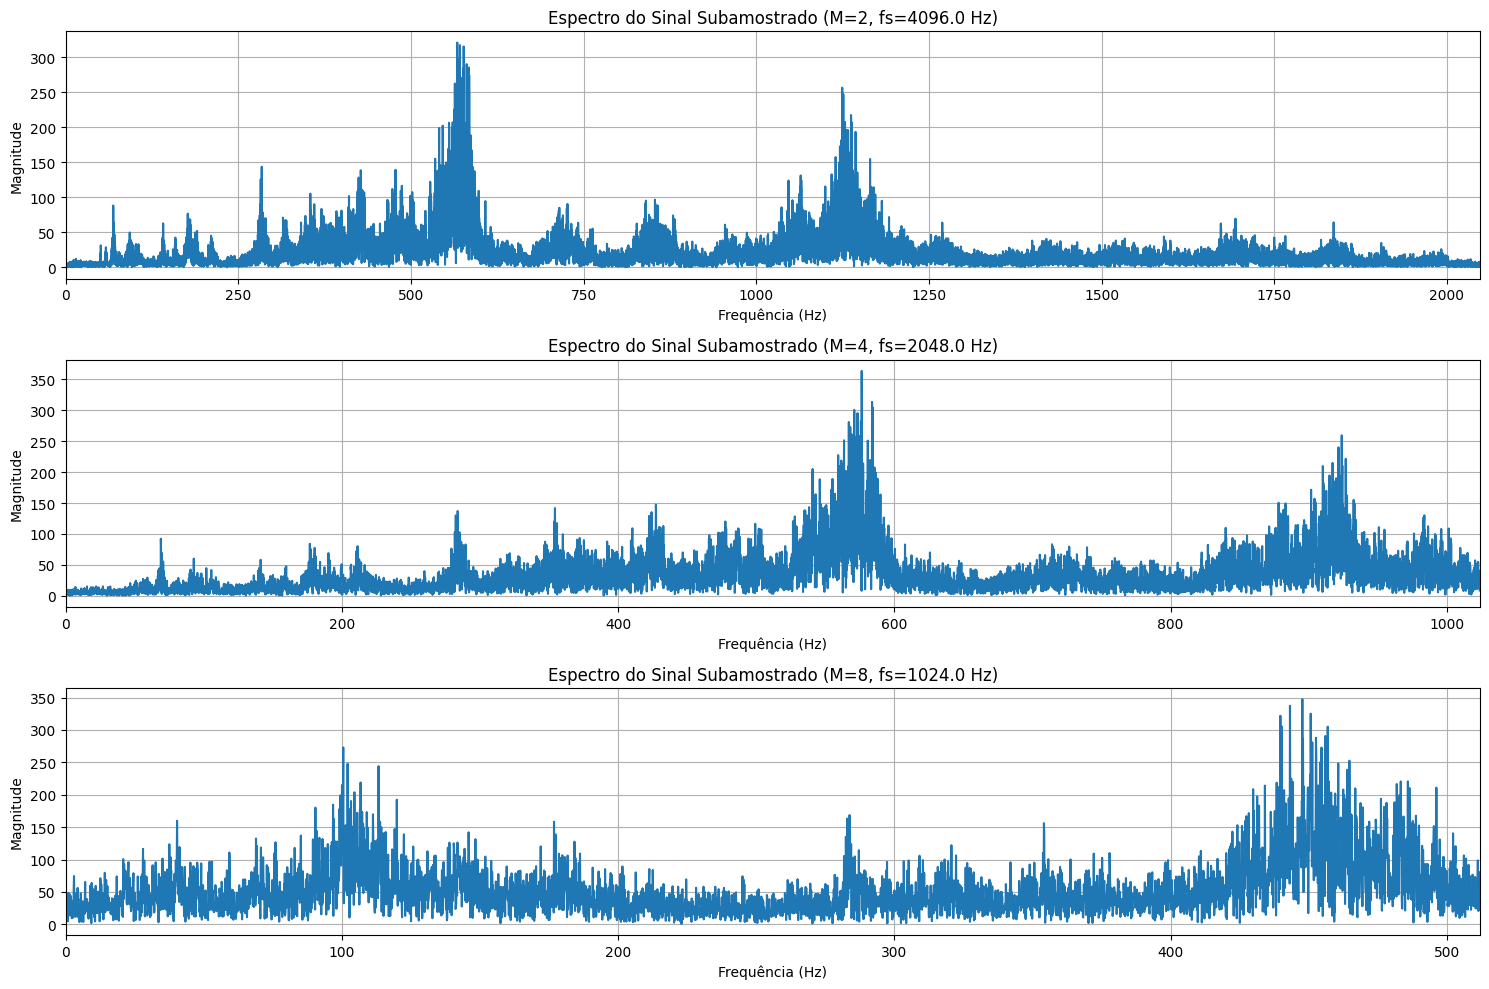

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


def downsample_signal(signal, M):
    """
    Realiza a subamostragem (downsampling) de um sinal discreto por um fator M.
    A relação é dada por y[n] = x[nM].

    Args:
        signal (np.ndarray): O sinal discreto original.
        M (int): O fator de subamostragem. Deve ser um inteiro positivo.

    Returns:
        np.ndarray: O sinal subamostrado.
    """
    if not isinstance(M, int) or M <= 0:
        raise ValueError("O fator de subamostragem M deve ser um inteiro positivo.")

    # Seleciona cada M-ésima amostra do sinal original
    downsampled_signal = signal[::M]
    return downsampled_signal


downsample_factors = [2, 4, 8]

plt.figure(figsize=(15, 10))

for i, M_downsample in enumerate(downsample_factors):
    # Aplica a função de subamostragem ao sinal de áudio original
    downsampled_signal = downsample_signal(signal_audio, M=M_downsample)

    # A nova frequência de amostragem será fs_audio / M
    new_fs = fs_audio / M_downsample

    # Calcula o espectro do sinal subamostrado
    freqs_downsampled, spectrum_downsampled = calculate_spectrum(downsampled_signal, new_fs)

    # Plot the spectrum
    plt.subplot(len(downsample_factors), 1, i + 1)
    plt.plot(freqs_downsampled, spectrum_downsampled)
    plt.title(f'Espectro do Sinal Subamostrado (M={M_downsample}, fs={new_fs:.1f} Hz)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude')
    plt.xlim(0, new_fs / 2) # Show up to Nyquist frequency of the downsampled signal
    plt.grid(True)

plt.tight_layout()
plt.show()


Agora você pode analisar os espectros dos sinais subamostrados e observar as diferenças em relação ao sinal original, especialmente em termos da frequência de Nyquist e da presença de possível aliasing.

In [20]:
import scipy.io.wavfile as wavfile
import numpy as np

def downsample_signal(signal, M):
    """
    Realiza a subamostragem (downsampling) de um sinal discreto por um fator M.
    A relação é dada por y[n] = x[nM].

    Args:
        signal (np.ndarray): O sinal discreto original.
        M (int): O fator de subamostragem. Deve ser um inteiro positivo.

    Returns:
        np.ndarray: O sinal subamostrado.
    """
    if not isinstance(M, int) or M <= 0:
        raise ValueError("O fator de subamostragem M deve ser um inteiro positivo.")

    # Seleciona cada M-ésima amostra do sinal original
    downsampled_signal = signal[::M]
    return downsampled_signal

downsample_factors = [2, 4, 8]

print("Gerando arquivos de áudio subamostrados...")

for M_downsample in downsample_factors:
    # Aplica a função de subamostragem ao sinal de áudio original
    downsampled_signal = downsample_signal(signal_audio, M=M_downsample)

    # A nova frequência de amostragem será fs_audio / M
    new_fs = int(fs_audio / M_downsample)

    # Certifica-se de que o sinal está no formato correto para wav (int16)
    # Se o sinal original for int16, a subamostragem não mudará o tipo.
    # Se for de outro tipo, pode ser necessário converter. Assume-se int16 aqui.
    if downsampled_signal.dtype != np.int16:
        downsampled_signal = downsampled_signal.astype(np.int16)

    output_filename = f'/content/handel_downsampled_M{M_downsample}.wav'
    wavfile.write(output_filename, new_fs, downsampled_signal)
    print(f'Arquivo gerado: {output_filename} com fs = {new_fs} Hz')

print("Processo concluído. Você pode encontrar os arquivos .wav na pasta /content.")


Gerando arquivos de áudio subamostrados...
Arquivo gerado: /content/handel_downsampled_M2.wav com fs = 4096 Hz
Arquivo gerado: /content/handel_downsampled_M4.wav com fs = 2048 Hz
Arquivo gerado: /content/handel_downsampled_M8.wav com fs = 1024 Hz
Processo concluído. Você pode encontrar os arquivos .wav na pasta /content.


Os arquivos de áudio subamostrados foram gerados e salvos na pasta `/content/`. Você pode baixá-los e ouvi-los para perceber o efeito da subamostragem.

Você pode agora usar `downsampled_signal_audio` e `new_fs_audio` para, por exemplo, ouvir o áudio subamostrado ou calcular seu novo espectro.